In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

In [24]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv(
    "../data/processed/clean_nav.csv"
)

sip = pd.read_csv(
    "../data/raw/04_monthly_sip_inflows.csv"
)

transactions = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

performance = pd.read_csv(
    "../data/processed/clean_performance.csv"
)

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

In [25]:
nav['date'] = pd.to_datetime(nav['date'])

fig = px.line(
    nav,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trend (2022-2026)'
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run"
)

fig.add_vrect(
    x0="2024-04-01",
    x1="2024-09-30",
    annotation_text="2024 Correction"
)

fig.show()

In [26]:
fig.write_image(
    "../charts/nav_trend.png"
)

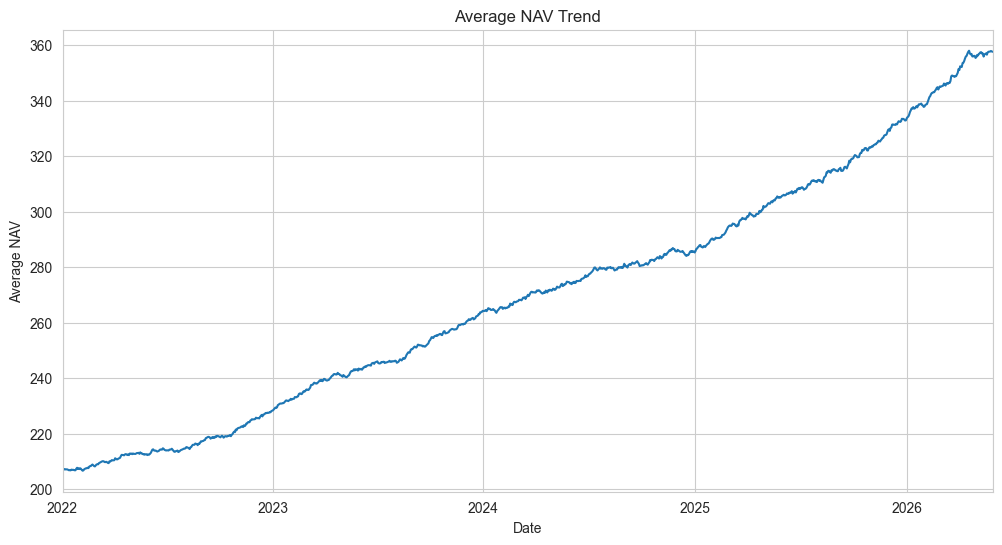

In [27]:
avg_nav = nav.groupby('date')['nav'].mean()

plt.figure(figsize=(12,6))
avg_nav.plot()

plt.title('Average NAV Trend')
plt.xlabel('Date')
plt.ylabel('Average NAV')

plt.savefig(
    '../charts/average_nav_trend.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [28]:
aum = pd.read_csv(
    "../data/raw/03_aum_by_fund_house.csv"
)

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [29]:
aum['date'] = pd.to_datetime(aum['date'])

In [30]:
aum['year'] = aum['date'].dt.year

In [31]:
aum[['date','year']].head()


,date,year
0,2022-03-31,2022
1,2022-03-31,2022
2,2022-03-31,2022
3,2022-03-31,2022
4,2022-03-31,2022


In [32]:
aum_yearly = (
    aum.groupby(['year','fund_house'])
       ['aum_lakh_crore']
       .mean()
       .reset_index()
)
aum_yearly.head()

,year,fund_house,aum_lakh_crore
0,2022,Aditya Birla Sun Life MF,2.815
1,2022,Axis Mutual Fund,2.450
2,2022,DSP Mutual Fund,1.110
3,2022,HDFC Mutual Fund,4.400
4,2022,ICICI Prudential MF,4.765


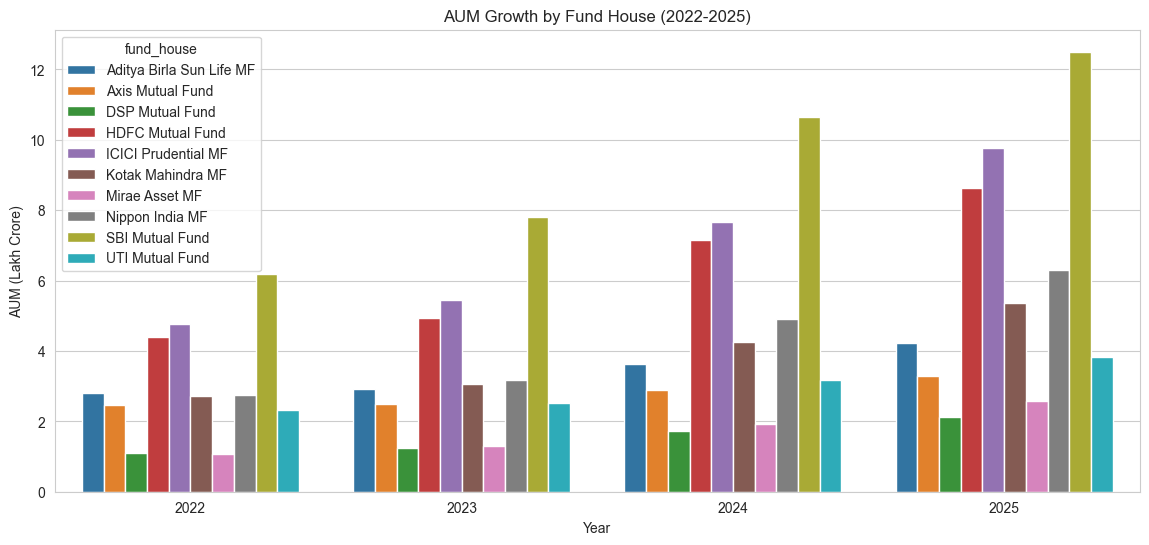

In [33]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_yearly,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title('AUM Growth by Fund House (2022-2025)')
plt.xlabel('Year')
plt.ylabel('AUM (Lakh Crore)')
plt.xticks(rotation=0)

plt.savefig(
    "../charts/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
sip['month'] = pd.to_datetime(
    sip['month']
)

In [35]:
fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend'
)

fig.add_annotation(
    x='2025-12-01',
    y=31002,
    text='₹31,002 Cr ATH'
)

fig.show()

In [36]:
fig.write_image(
    "../charts/sip_trend.png"
)

In [37]:
category_flows = pd.read_csv(
    "../data/raw/05_category_inflows.csv"
)

category_flows.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


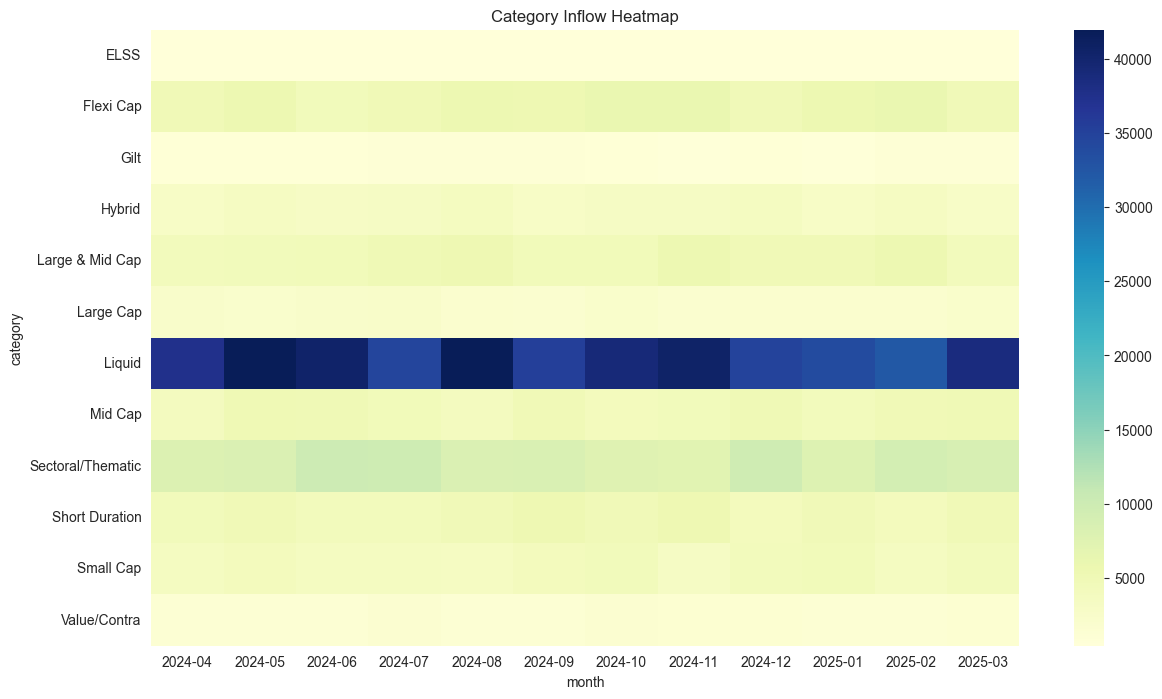

In [68]:
heatmap_data = (
    category_flows
    .pivot(
        index='category',
        columns='month',
        values='net_inflow_crore'
    )
)

plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title(
    'Category Inflow Heatmap'
)

plt.savefig(
     "../charts/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

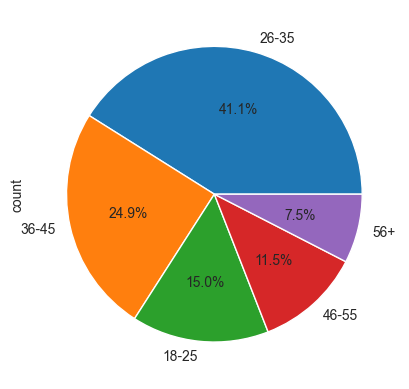

In [69]:
transactions[
'age_group'
].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)
plt.savefig(
    '../charts/age_group_distribution.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

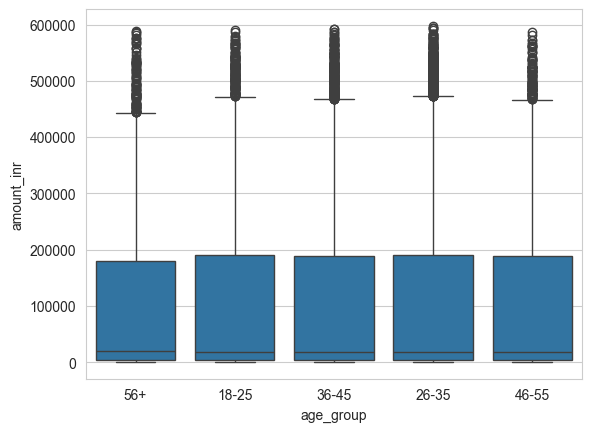

In [70]:
sns.boxplot(
    data=transactions,
    x='age_group',
    y='amount_inr'
)
plt.savefig(
    '../charts/sip_amount_age_boxplot.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

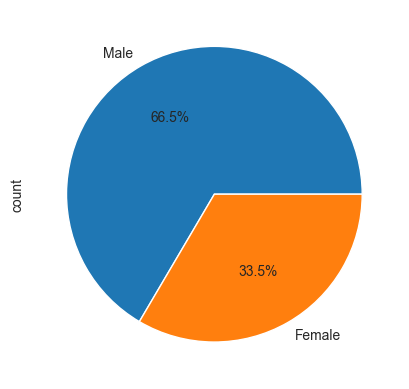

In [71]:
transactions[
'gender'
].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)
plt.savefig(
    '../charts/gender_distribution.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

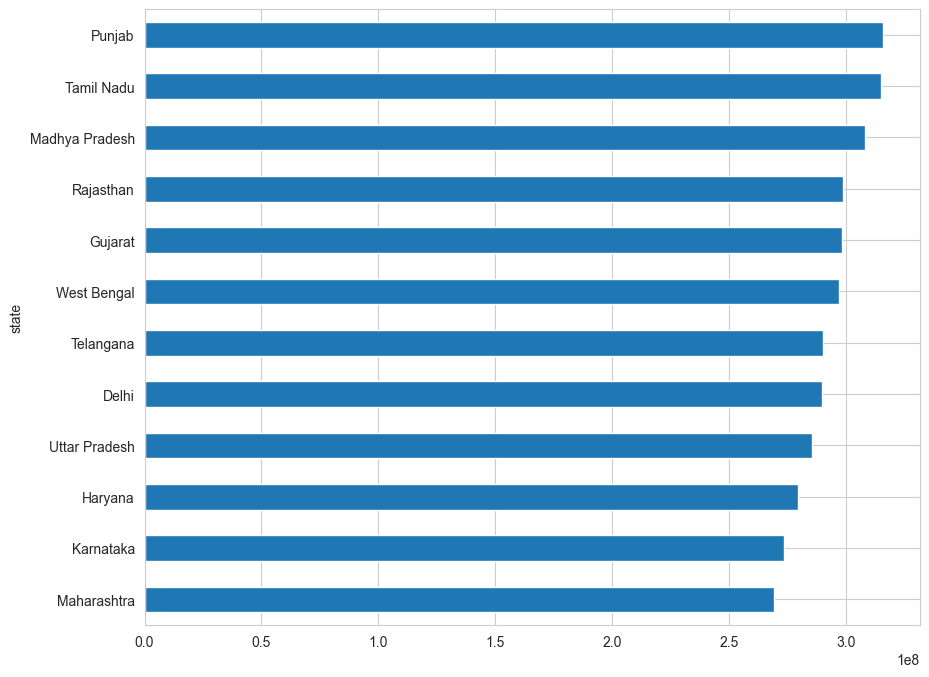

In [72]:
state_data = (
transactions.groupby('state')
['amount_inr']
.sum()
.sort_values()
)

state_data.plot(
kind='barh',
figsize=(10,8)
)
plt.savefig(
    '../charts/state_wise_sip_amount.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

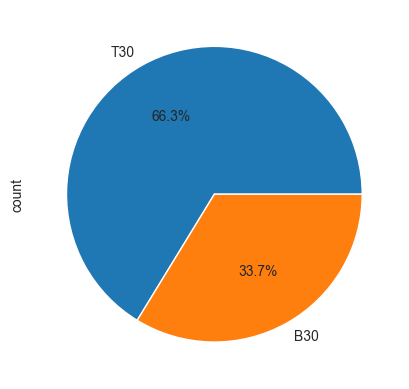

In [75]:
transactions[
'city_tier'
].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)

plt.savefig(
    '../charts/city_tier_distribution.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [50]:
folio = pd.read_csv(
    "../data/raw/06_industry_folio_count.csv")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [51]:
fig = px.line(
    folio,
    x='month',
    y='total_folios_crore'
)

In [ ]:
fig.add_annotation(
x='2022-01-01',
y=13.26,
text='13.26 Cr'
)

fig.add_annotation(
x='2025-12-01',
y=26.12,
text='26.12 Cr'
)


In [77]:
fig.write_image(
    '../charts/folio_growth.png',
    width=1200,
    height=700
)

In [54]:
nav.head()

,amfi_code,date,nav,daily_return_pct
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-1.030568
2,100016,2022-01-05,521.7239,1.286515
3,100016,2022-01-06,515.7880,-1.137747
4,100016,2022-01-07,515.1639,-0.120999


In [55]:
pivot = nav.pivot(
    index='date',
    columns='amfi_code',
    values='daily_return_pct'
)

In [56]:
corr = pivot.iloc[:,0:10].corr()

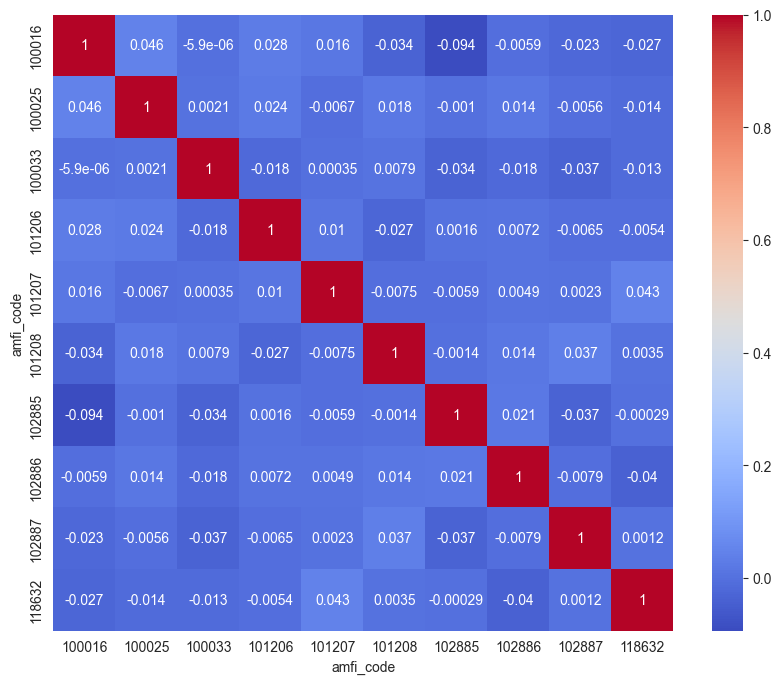

In [78]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.savefig(
    '../charts/nav_correlation_matrix.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [59]:
sector = (
holdings.groupby('sector')
['weight_pct']
.sum()
)

In [60]:
fig = go.Figure(
go.Pie(
labels=sector.index,
values=sector.values,
hole=0.5
)
)

fig.show()

In [61]:
fig.write_image(
    '../charts/sector_allocation_donut.png',
    width=1200,
    height=700
)


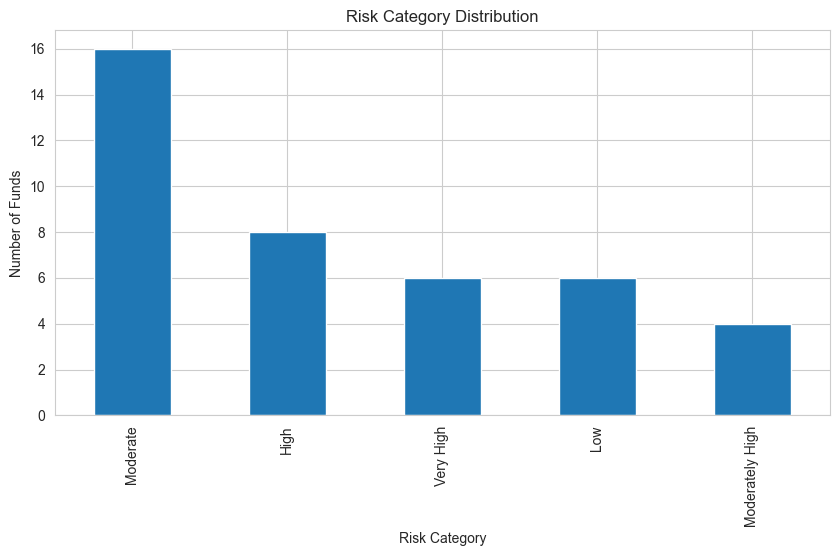

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

fund_master['risk_category'].value_counts().plot(
    kind='bar'
)

plt.title('Risk Category Distribution')
plt.xlabel('Risk Category')
plt.ylabel('Number of Funds')

plt.savefig(
    '../charts/risk_category_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

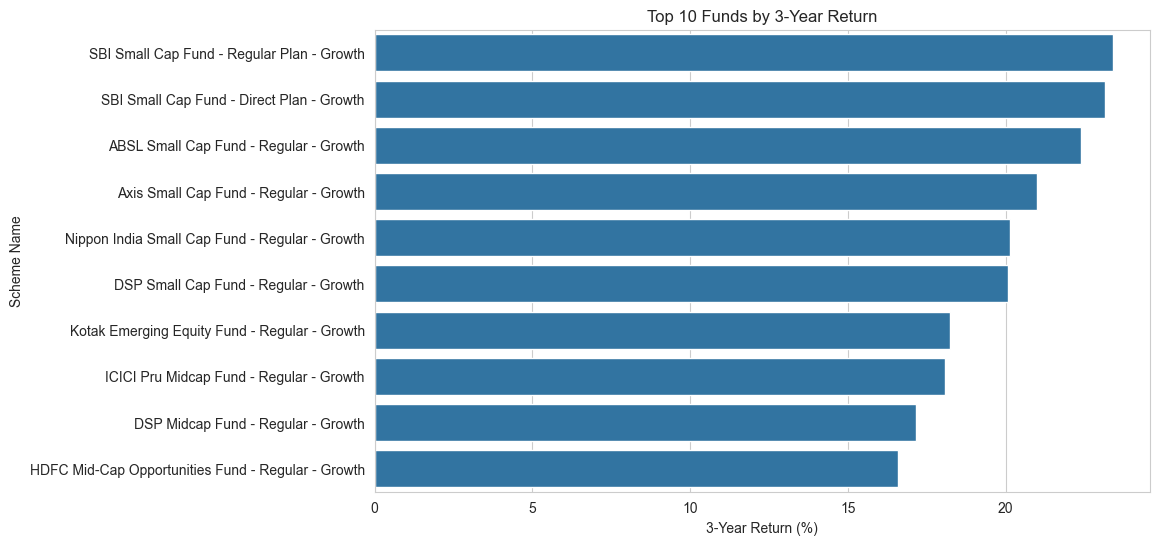

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

top_funds = (
    performance
    .sort_values(
        'return_3yr_pct',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_funds,
    x='return_3yr_pct',
    y='scheme_name'
)

plt.title('Top 10 Funds by 3-Year Return')
plt.xlabel('3-Year Return (%)')
plt.ylabel('Scheme Name')

plt.savefig(
    '../charts/top_10_funds_return.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#1 SIP Inflows Reached Record High

SIP inflows showed a consistent upward trend from 2022 to 2025, reaching an all-time high of ₹31,002 crore in December 2025. This indicates increasing investor confidence and growing participation in systematic investment plans.


#2 Strong NAV Growth During 2023 Bull Run

Most mutual fund schemes experienced significant NAV appreciation during 2023, reflecting favorable market conditions and strong equity market performance throughout the year.


#3 Market Correction Observed in 2024

A temporary slowdown and correction in NAV growth was observed during 2024, indicating increased market volatility and profit-booking activities among investors.


#4 SBI Mutual Fund Dominates Industry AUM

SBI Mutual Fund maintained the highest Assets Under Management (AUM) among all fund houses, demonstrating strong market leadership and investor trust.


#5 Equity Funds Attract Maximum Investor Interest

Equity-oriented schemes accounted for the largest share of investments and fund offerings, highlighting investors' preference for long-term wealth creation through equity markets.


#6 Investors Aged 26–45 Form the Largest Segment

The majority of investors belong to the 26–35 and 36–45 age groups, indicating that working professionals are the primary contributors to mutual fund investments.


#7 T30 Cities Contribute Majority of Investments

Investors from T30 (Top 30) cities generated a larger share of total investment volume compared to B30 cities, reflecting higher financial awareness and participation in urban regions.


#8 Significant Geographic Concentration of Investments

A few states contribute a disproportionately large share of total SIP investments, suggesting that mutual fund penetration remains concentrated in specific regions of India.


#9 Positive Correlation Among Equity Fund Returns

The correlation matrix revealed strong positive relationships among several equity funds, indicating that many schemes respond similarly to broader market movements.


#10  Higher Sharpe Ratio Funds Deliver Better            Risk-Adjusted Returns

Funds with higher Sharpe Ratios generally demonstrated superior risk-adjusted performance, making them more attractive for investors seeking efficient returns relative to risk.

